# Adaptive PDE discretizations on cartesian grids
## Volume : Algorithmic tools
## Part : Generalized acuteness
## Chapter : Angular distorsion of Seismic norms

The propagation speed of seismic waves is governed by the elastic properties of the medium, encoded in a Hooke tensor $c$. The dependency is non-linear and rather complex from the algebraic point of view, involving a polynomial constraint of degree six in three variables. In this notebook, we provide some detail on the definition and numerical computation of these quantities, and extract some quantities of interest for the fast marching method.

[**Summary**](Summary.ipynb) of volume Algorithmic tools, this series of notebooks.

[**Main summary**](../Summary.ipynb) of the Adaptive Grid Discretizations 
	book of notebooks, including the other volumes.

# Table of contents
  * [1. Geometric distorsion](#1.-Geometric-distorsion)
    * [1.1 Length distorsion](#1.1-Length-distorsion)
    * [1.2 Angular distortion](#1.2-Angular-distortion)
  * [2. Convexity of the constraint](#2.-Convexity-of-the-constraint)
    * [2.1 Quasi-convexity](#2.1-Quasi-convexity)
    * [2.2 Relaxation parameter](#2.2-Relaxation-parameter)



**Acknowledgement.** The experiments presented in these notebooks are part of ongoing research, 
some of it with PhD student Guillaume Bonnet, in co-direction with Frederic Bonnans, 
and PhD student François Desquilbet, in co-direction with Ludovic Métivier.

Copyright Jean-Marie Mirebeau, University Paris-Sud, CNRS, University Paris-Saclay

## 0. Importing the required libraries

In [1]:
import sys; sys.path.insert(0,"../..") # Allow import of agd from parent directory (useless if conda package installed)
#from Miscellaneous import TocTools; print(TocTools.displayTOC('SeismicNorm','Algo'))

In [2]:
from agd.Metrics.Seismic import Hooke,Thomsen
from agd.Metrics import Riemann
from agd import LinearParallel as lp
from agd import AutomaticDifferentiation as ad
from agd.Plotting import SetTitle3D

In [37]:
import numpy as np
import copy
from matplotlib import pyplot as plt

## 1. Geometric distorsion

Norms arising in seismology have a fairly complex expression, but eventually their anisotropy is rather mild in comparison with other applications.
We illustrate this point by computing the length distortion associated with several geologic materials. We then estimate the angular distortion, which is directly related with the applicability of the fast marching method.

The algebraic expression of seismic norm is not used in this section, or any of its properties, except for symmetry (which allows to consider only half of the unit sphere).

### 1.1 Considered norms

The various geologic materials yield different types of anisotropies. We select a few for illustration.
The level sets of the norm illustrate the distance that the seismic waves can reach in a given time, which depends on their direction of propagation.

In [4]:
# Two specific examples
norm2 = Hooke.mica[0].extract_xz().rotate_by(0.3) 
norm3 = Hooke.mica[0].rotate_by(0.8,axis=(1,2,3))

In [5]:
# Some more examples
norms2 = [
    ("riemann2",Riemann.from_diagonal([1,3**2]).rotate_by(0.7)),
    ("mica2",Hooke.mica[0].extract_xz().rotate_by(1.2)),
    ("stishovite2",Hooke.stishovite[0].extract_xz().rotate_by(-0.5)),
    ("mudshale2",Hooke.from_Thomsen(Thomsen.ThomsenData["Mesaverde (4903) mudshale"])[0].extract_xz().rotate_by(-0.5)),
]
norms3 = [
    ("mica3",Hooke.mica[0].rotate_by(0.3,axis=(1,2,3))),
    ("stishovite3",Hooke.stishovite[0].rotate_by(0.8,axis=(1,1,1))),
]

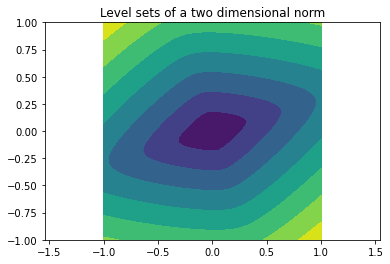

In [6]:
aX = np.linspace(-1,1)
X = np.meshgrid(aX,aX,indexing='ij')
plt.title("Level sets of a two dimensional norm"); plt.axis('equal');
plt.contourf(*X,norm2.norm(X)); 

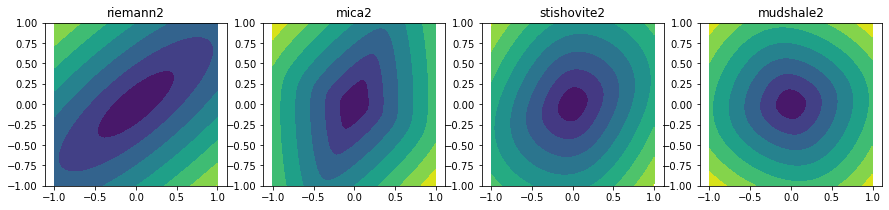

In [7]:
plt.figure(figsize=[15,3])
for i,(name,norm) in enumerate(norms2):
    plt.subplot(1,len(norms2),1+i)
    plt.title(name); plt.axis('equal')
    plt.contourf(*X,norm.norm(X))

### 1.2 Half sphere sampling

We study the behavior of our norms on the Euclidean unit sphere, in order to quantify their length distortion.
Since the norms are symmetric w.r.t the origin, it is enough to sample the half sphere.

We use $n=20$ points in the illustrations below, but $n=40$ in the experiments by default. This sampling of the unit sphere is already rather dense, and is enough to extract the numerical information.

In [8]:
def HalfSphereSampling(vdim,dens=40):
    """
    Produces a rather uniform sampling of the upper half of the unit sphere.
    - vdim (in [2,3]) : dimension of the sphere
    - dens : sampling density. dens**(vdim-1) points are returned.
    """
    if vdim==2: 
        θs = np.linspace(0,np.pi,dens,endpoint=False)
        return np.array([np.cos(θs),np.sin(θs)])
    elif vdim==3:
        θs = np.linspace(0,np.pi/2,dens//2)
        ϕs = np.linspace(0,2*np.pi,2*dens,endpoint=False)
        return np.array([(np.cos(θ)*np.cos(ϕ), np.cos(θ)*np.sin(ϕ), np.sin(θ)) for θ in θs for ϕ in ϕs]).T
    else: 
        raise ValueError("Unsupported dimension")

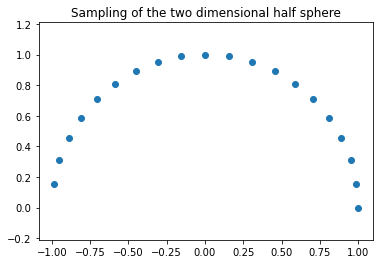

In [9]:
plt.title("Sampling of the two dimensional half sphere")
plt.scatter(*HalfSphereSampling(2,20));plt.axis('equal');

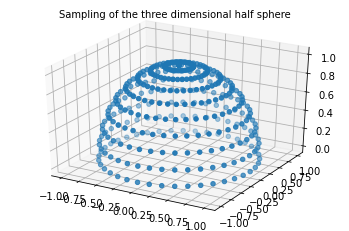

In [10]:
ax = plt.figure().gca(projection='3d')
SetTitle3D(ax,"Sampling of the three dimensional half sphere")
ax.scatter(*HalfSphereSampling(3,20));

### 1.1 Length distorsion

A natural measure of the anisotropy associated with a norm is its maximal length distortion
$$
    \mu(N) := \max_{|u|=|v|=1} \frac {N(u)}{N(v)}.
$$
This quantity is to the ratio of the largest propagation speed, divided by the smallest propagation speed, over all space orientations.

In [11]:
def LengthDistortion(norm,**kwargs):
    p = HalfSphereSampling(norm.vdim,**kwargs)
    Np = norm.norm(p)
    return np.max(Np)/np.min(Np)

The mica medium has a length distortion of approximately $1.8$, which is large for a geological material (that is because mica is a crystal). Note that, with other types of norms, the HFM library routinely handles norms with length distortion exceeding $10$.

In [12]:
LengthDistortion(norm2)

1.826531520777687

By construction, length distortion is invariant under rotation of the norm. The (very small) difference arises because we use a finite sampling of the sphere.

In [13]:
LengthDistortion(norm2.rotate_by(np.pi/3))

1.827030499135136

Because mica is transversally isotropic, the length distortion of the three dimensional mica norm is equivalent.

In [14]:
LengthDistortion(norm3)

1.828319629004346

For Riemannian norms, the length distortion can be computed in closed form, and is provided as the `anisotropy` member function. (In contrast, there is no simple closed form expression for the anisotropy of Seismic norms to our knowledge, and the `anisotropy` method is thus not implemented.) 

In [15]:
name,norm = norms2[0]
print(f"Norm : {name}. Length distortion : approximate {LengthDistortion(norm)}, exact {norm.anisotropy()}")

Norm : riemann2. Length distortion : approximate 2.999373021225439, exact 3.0


In [16]:
for name,norm in norms2+norms3:
    print(f"Norm {name}. Length distortion {LengthDistortion(norm)}")

Norm riemann2. Length distortion 2.999373021225439
Norm mica2. Length distortion 1.8240126561699315
Norm stishovite2. Length distortion 1.308367631573457
Norm mudshale2. Length distortion 1.069792997821059
Norm mica3. Length distortion 1.8282899187030757
Norm stishovite3. Length distortion 1.3084655222014125


### 1.2 Angular distortion

The Fast-Marching method relies on a *causality property*, ensuring that the front arrival time at a given point can be computed in terms of neighbors earlier reached, and thus that the non-linear system of equations discretizing the PDE can be solved in a single pass.

For Seismic norms, we rely on a semi-lagrangian discretization of the eikonal equation, based on fixed stencils (illustrated below). In this context, the *causality property* follows from a geometrical *acuteness property*, as already observed by Sethian et al. The acuteness property requires that 
$$
    \Theta(N) + \Theta(V) < \pi/2,
$$
where $N$ is the norm, and $V$ is the stencil used for the PDE discretization.
We denoted:
* $\Theta(N)$ the angular distortion of the norm, defined as the largest (unoriented) angle between $p$ and $\nabla N(p)$, for each non-zero vector $p$. (By homogeneity, it suffices to consider the unit sphere.)
* $\Theta(V)$ the angular width of the stencil, defined as the largest (unoriented) angle between two vertices of a facet of the stencil.

The some standard stencils are illustrate below, whose angular width $\Theta(V)$ is easily computed:

Stencil | Dimension | Angular width $\Theta(V)$
--- | --- | ---
Square | 2 | $\pi/4$
Cut-cube | 3 | $\pi/3$
Cube | 3 | $0.955..$
Spiky-cube | 3 | $\pi/4$

(The exact angular width of the cube stencil is $\arccos(1/\sqrt 3)$.)

**In practice, for Seismic norms.** Most norms corresponding to geologic materials are only midly anisotropic, so that the square stencil can be used in two dimensions, and the cut-cube in three dimensions. This is not true however of crystals, such as mica chosen as an exemple, which exhibit stronger anisotropy and require more the refined spiky-cube in three dimensions. 

**In practice, for strongly anisotropic norms arising in other applications.** The use of fixed stencils is inadequate when the anisotropy is strong, and one must instead produce adaptive and anisotropic stencils, using mathematical tools such as the [Stern-Brocot tree](SternBrocot.ipynb) and [Voronoi vectors](VoronoiVectors.ipynb).

![](FixedStencils.png)

The angular distortion of a norm is numerically evaluated by the next function.

In [17]:
def AngularDistortion(norm,**kwargs):
    p = HalfSphereSampling(norm.vdim,**kwargs)
    dNp = norm.gradient(p)
    ratio = lp.dot_VV(p,dNp)/np.linalg.norm(dNp,ord=2,axis=0)
    return np.arccos(np.min(ratio))

The angular distortion of the mica medium is less than $\pi/4$, which allows using the square stencil (in two dimensions), and the spiky cube stencil (in three dimensions).

In [18]:
μ = AngularDistortion(norm2)
print(f"Angular distortion of mica : {μ}, pi/4 : {np.pi/4}")

Angular distortion of mica : 0.7509887694791147, pi/4 : 0.7853981633974483


Note that angular distortion is invariant under rotation (up to numerical accuracy due to the finite sampling of the sphere).

In [19]:
AngularDistortion(norm2.rotate_by(1.2))

0.7497254150260351

Since the mica medium is transversally isotropic, the angular distortion of the three dimensional medium is identical (again up to numerical accuracy).

In [20]:
AngularDistortion(norm3)

0.7528581192017462

Angular distortion is bounded in terms of the Length distortion : one has $\mu(N) \cos \Theta(N) \geq 1$.

In [21]:
LengthDistortion(norm2) * np.cos(AngularDistortion(norm2))

1.3352210770062627

In the case of Riemannian metrics, the angular distortion has a closed form expression, just as the length distortion, and they are related by $(\mu(N)+\mu(N)^{-1})\cos \Theta(N) = 2$. Let us check this expression numerically.

In [22]:
name,norm = norms2[0]
μ = norm.anisotropy()
Θ = AngularDistortion(norm)
print(f"Norm {name}. Angular distortion : approximate {Θ}, exact {np.arccos(2/(μ+1/μ))} ")

Norm riemann2. Angular distortion : approximate 0.927293782652607, exact 0.9272952180016123 


In [23]:
for name,norm in norms2+norms3:
    print(f"Norm {name}. Angular distortion {AngularDistortion(norm)}")

Norm riemann2. Angular distortion 0.927293782652607
Norm mica2. Angular distortion 0.7521110091600806
Norm stishovite2. Angular distortion 0.3126982198178143
Norm mudshale2. Angular distortion 0.12435235682165967
Norm mica3. Angular distortion 0.752859677386624
Norm stishovite3. Angular distortion 0.34104154422640154


The upper bound on the angular width $\Theta(N)$ for the applicability of the fast-marching method with the cut-cube stencil, in three dimensions, is 
$\pi/2 - \Theta(\text{cut-cube}) = \pi/6$. As mentioned above, it is satisfied for all common geological materials, except crystals (such as mica).

In [24]:
np.pi/6

0.5235987755982988

## 2. Convexity of the constraint

In this section, we discuss in more detail the computational aspects of Seismic norms. 
For that purpose, let us fix a Hooke tensor $c$ of components $c_{ijkl}$ where $i,j,k,l \in \{1,\cdots,d\}$.


**Definition of the Seismic norm.**
For each vector $v \in R^d$ define a $d \times d$ symmetric matrix $m(v)$ of components 
$$
    m_c(v)_{ik} = \sum_{j,l} c_{ijkl} v_j v_l.
$$
In view of energetic considerations, one assumes that the Hooke tensor $c$ is positive (in an appropriate sense), which implies that $m(v)$ is a positive semi-definite matrix for each $v \in R^d$.

The *dual norm* to a seismic metric is defined as the square root of the largest eigenvalue of the matrix $m_c(v)$
$$
    N_c^*(v) := \sqrt{\lambda_{\max}(m_c(v))},
$$
whereas the primal norm is defined dually, for all $w \in R^d$
$$
    N_c(w) := \max \{<w,v>;\ N_c^*(w) \leq 1\}.
$$
One can prove that $N_c^*$ is a norm is a norm, and in particular it is convex, so that $N_c$ is defined as the maximization of a linear objective function subject to a convex constraint.

**Efficient numerical computation.**
Despite being well posed, the above definition of $N_c$ is not very tractable numerically, due to the complex and costly evaluation of $N_c^*$.
Instead, let us define 
$$
    f_c(v) := \det(I - m_c(v)),
$$
so that the (closed) dual unit ball $B_c^*$ admits the equivalent characterizations
$$
B_c^* 
:= 
\{v; N_c^*(v) \leq 1\}
=
\text{CC}_0(\{f_c(v) \geq 0\}),
$$
where $\text{CC}_x(X)$ denotes the connected component of the point $x$ in the set $X$. We can thus rephrase the definition of $N_c$, with a slight abuse of notation, as 
$$
    N_c(w) := \{<w,v>;\ f_c(v) \geq 0,\ v \in \text{CC}_0\}.
$$
We have replaced the highly non-linear constraint $N^*_c(v)\leq 1$ with the polynomial constraint $f_c(v) \geq 0$, which is much more tractable numerically (in particular it is easy to differentiate). Note that $f_c$ is an in-homogeneous polynomial of degree $2d$ in $d$ variables, where $f\in \{2,3\}$ is the dimension.

**Convexity.** 
The dual norm $N_c^*$ is convex, as mentioned above, but properties of $f_c$ are slightly more subtle. 
One can show that:
* $f_c$ is quasi-concave on a neighborhood of $B_c^*$. (In other words the sets of $\{v \in B_c^*; f_c\geq \lambda\}$ are convex for all $\lambda$.)
* $f_c^{\frac 1 d}$ is strongly concave on $B_c^*$. Note that this function in not defined outside $B_c^*$.
* $\exp(-\alpha f_c)$ is strongly convex on a neighborhood of $B_c^*$, for sufficiently large $\alpha$.

The constraint function $f_c$ is a hidden method of the dual norm, shown below.

In [25]:
def F(norm,v): return -norm._dual_level(v) # Constraint function f_c

### 2.1 Quasi-concavity

The dual unit ball $B_c^*$ is the connected component of the origin delimited by the level set $f_c=0$, shown red.
As announced, the level sets of $\{f_c\geq \lambda\}$ within this region are convex, reflecting the quasi-concavity.

In [26]:
aX = np.linspace(-0.3,0.3)
X = np.array(np.meshgrid(aX,aX,indexing='ij'))
X_ad = ad.Dense2.identity(constant=X,shape_free=(2,))

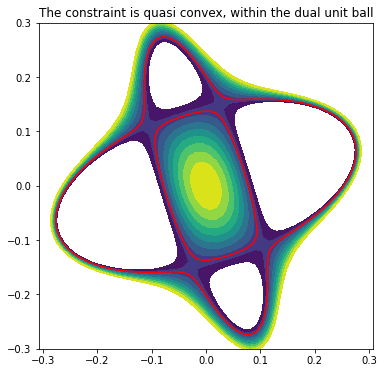

In [27]:
plt.figure(figsize=(6,6)); plt.axis('equal');
plt.title("The constraint is quasi convex, within the dual unit ball")
f = F(norm2,X)
plt.contourf(*X,f,np.linspace(-0.2,1,10))
plt.contour(*X,f,[0],colors='red');

The function $f_c$ is however *not* concave in $B_c^*$. Indeed, as illustrated below, the determinant of the hessian of $f_c$ changes sign in this region. 

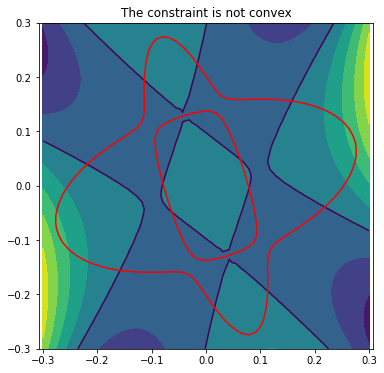

In [28]:
plt.figure(figsize=(6,6)); plt.axis('equal');
plt.title("The constraint is not convex")
f_ad = F(norm2,X_ad)
f = f_ad.value
det_h = lp.det(f_ad.hessian())
plt.contourf(*X,det_h)
plt.contour(*X,det_h,[0])
plt.contour(*X,f,[0],colors='red');

The function $f_c^{\frac 1 d}$ is strongly concave in $B_c^*$, and indeed its hessian is negative definite in the interior of this region. However $f_c^{\frac 1 d}$ is not very nice to use numerically due to the singularity on the boundary of $B_c^*$. 

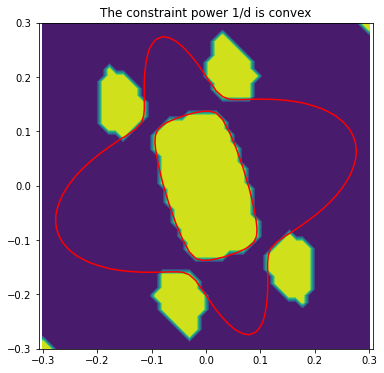

In [30]:
plt.figure(figsize=(6,6)); plt.axis('equal');
plt.title("The constraint power 1/d is convex")
f_pow_ad = np.maximum(0,F(norm2,X_ad))**(1/norm.vdim)
det_h_pow = lp.det(f_pow_ad.hessian())
plt.contourf(*X,det_h_pow>0)
plt.contour(*X,f_ad.value,[0],colors='red');

### 2.2 Convexity of $\exp(-\alpha f_c)$.

The function $\exp(-\alpha f_c)$ is known to be strongly convex on a neighborhood $B_c^*$, for sufficiently large $\alpha$, but the theoretical analysis is not quantitative. 
The next function estimates numerically the lower bound on the values of $\alpha$ which achieve this property.

Note that the strong convexity of a smooth function $\exp(-\alpha f)$ is equivalent to the pointwise positive definiteness property
$$
    \alpha \nabla f \nabla f^T - \nabla^2 f \succ 0.
$$

In [31]:
def LowerAlpha(norm,**kwargs):
    # Evaluate the dual norm on the Euclidean sphere
    p = HalfSphereSampling(norm.vdim,**kwargs)
    norm_pp = norm.contract(p)
    dual_norm = np.sqrt(np.linalg.norm(norm_pp,ord=2,axis=(0,1)))
    
    # Produce a sampling of the dual unit sphere, evaluate the constraint and derivatives
    q = p/dual_norm 
    q_ad = ad.Dense2.identity(constant=q,shape_free=(norm.vdim,))
    dual_level_ad = norm._dual_level(q_ad)
    assert np.allclose(dual_level_ad.value,0) 
    
    # Compute the minimal relaxation parameter
    h = dual_level_ad.hessian()
    g = dual_level_ad.gradient()
    λ = ad.Dense.identity(constant=1.)
    det_ad = lp.det(h + λ * lp.outer_self(g)) # Polynomial of degree one w.r.t λ
    α = -det_ad.value/det_ad.coef
    
    return np.max(α)

In practice, the exponential $\exp(-\alpha f_c)$ takes rather extreme values, which makes this quantity unfriendly from the numerical point of view due to the risk of overflow.

In [32]:
α = LowerAlpha(norm2)
α

10.129535935595051

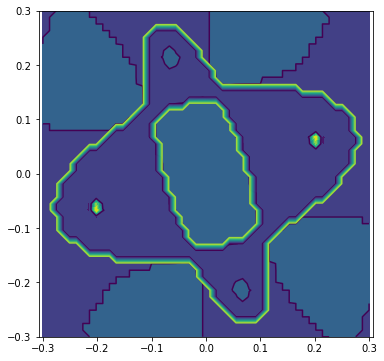

In [33]:
plt.figure(figsize=(6,6));plt.axis('equal');
exp_ad = np.exp(-α*F(norm2,X_ad))
value = exp_ad.value
det_h = lp.det(exp_ad.hessian())
plt.contourf(*X,det_h)
plt.contour(*X,det_h,[0])
plt.contour(*X,value<=1);

The hessian of $\exp(-\alpha f_c)$ is proportional to 
$$
    \alpha \nabla f_c \nabla f_c^T -\nabla^2 f_c.
$$
We check in the following illustration that it is positive definite within $B_c^*$ with our choice of $\alpha$. In addition, this hessian degenerates on the boundary of $B_c^*$, showing that $\alpha$ is indeed the lower bound.

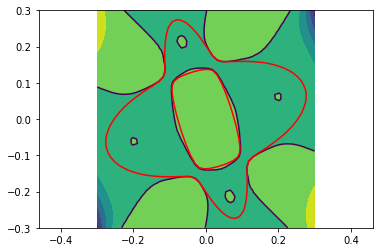

In [67]:
plt.axis('equal')
f_ad = F(norm2,X_ad)
v = f_ad.value
g = f_ad.gradient()
h = f_ad.hessian()
det_h = lp.det(α*lp.outer_self(g)-h)
plt.contourf(*X,det_h)
plt.contour(*X,det_h,[0])
plt.contour(*X,v,[0],colors='red');

In [35]:
for name,norm in norms2[1:]+norms3:
    print(f"Norm {name}. Lower bound on α {LowerAlpha(norm)}")

Norm mica2. Lower bound on α 10.13124253688134
Norm stishovite2. Lower bound on α 3.4964388394011827
Norm mudshale2. Lower bound on α -0.055859493172703945
Norm mica3. Lower bound on α 39.549249651079606
Norm stishovite3. Lower bound on α 61.21863144072934


If a parameter $\alpha$ has been determined (as above) such that $\alpha \nabla f_c \nabla f_c^T -\nabla^2 f_c \succ 0$, then it can be taken into account in the  Sequential Quadratically Constrained Programming (SQCP) routine used to compute the norm. This ensures that all inverted matrices are positive definite, and is in principle safer. Note that SQCP is an iterative method for solving problems of the form
$$
    \max \{<w,v>; f(v) \leq 0\},
$$
which is based on successively approximating $f$ with its second order Taylor expansion (the exact solution of this problem is known in closed form when the constraint is quadratic).


In numerical experiments, somewhat surprisingly, the SQCP method is rather insensitive to this parameter, and leaving it to the default value $\alpha=0$ appears to be fine. (Despite the lack of positive definiteness of $-\nabla^2 f_c$ on $B_c^*$, as observed above.)

In [68]:
def check_qconv(norm,α,**kwargs):
    norm_ = copy.copy(norm)
    norm_.qconv_sqp = α # Parameter such that α grad(f_c) grad (f_c)^T - hess(f_c) > 0
    norm_.niter_sqp = 12 # A few more iterations than default
    p = HalfSphereSampling(norm.vdim,**kwargs)
    return np.max(np.abs(norm.norm(p)-norm_.norm(p))) # Largest absolute error on unit ball

In [69]:
check_qconv(norm2,60.)

2.7755575615628914e-17

In [70]:
check_qconv(norm3,60.)

5.551115123125783e-17

In [75]:
for name,norm in norms2[1:]+norms3:
    print(f"Norm {name}, effect of $α$ {check_qconv(norm,60.)}")

Norm mica2, effect of $α$ 2.7755575615628914e-17
Norm stishovite2, effect of $α$ 1.3877787807814457e-17
Norm mudshale2, effect of $α$ 2.439454888092385e-19
Norm mica3, effect of $α$ 5.551115123125783e-17
Norm stishovite3, effect of $α$ 1.5334955527634975e-15
